In [1]:
# !pip install git+https://github.com/speechbrain/speechbrain.git@develop -q
# !pip install -q -U git+https://github.com/wenet-e2e/wespeaker.git -q
!pip install speechbrain
!pip install -q protobuf==3.20.2
!pip install -q pyroomacoustics
!pip install -q s3prl
!pip install -q whisper
!pip install -q onnxruntime

Defaulting to user installation because normal site-packages is not writeable
  Using cached ruamel_yaml-0.18.17-py3-none-any.whl.metadata (27 kB)
  Using cached ruamel_yaml_clib-0.2.15-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (3.5 kB)
Using cached ruamel_yaml-0.18.17-py3-none-any.whl (121 kB)
Using cached ruamel_yaml_clib-0.2.15-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (731 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda 23.5.2 requires ruamel-yaml<0.18,>=0.11.14, but you have ruamel-yaml 0.18.17 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3prl 0.4.18 requires protobuf>=4.21.1, but you have protobuf 3.20.2 whic

In [2]:
import os
import csv
import math
import yaml
import glob
import warnings
import numpy as np
import itertools
import matplotlib.pyplot as plt
import librosa
import scipy.signal as sps
# import pyroomacoustics as pra
from tqdm.autonotebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.compliance.kaldi as kaldi
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint, 
    LearningRateMonitor, 
    EarlyStopping, 
    Callback
)
from sklearn.metrics import (
    roc_curve, 
    auc, 
    confusion_matrix, 
    classification_report,
    precision_recall_fscore_support,
    accuracy_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    f1_score
)
from wespeaker.models.projections import ArcMarginProduct as ArcMarginProjection
from speechbrain.lobes.models.ECAPA_TDNN import ECAPA_TDNN
from speechbrain.processing.features import InputNormalization
from speechbrain.inference.speaker import EncoderClassifier

# Cấu hình bổ sung
warnings.filterwarnings('ignore')

/tmp/ipykernel_860719/3854660508.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/home/rnd_admin/.local/lib/python3.10/site-packages/s3prl/upstream/byol_s/byol_a/common.py:20: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")
ESPnet is not installed, cannot use espnet_hubert upstream


In [3]:
class HardAugmentor:
    def __init__(self, noise_dir=None, sr=16000):
        self.sr = sr
        self.noise_dir = noise_dir
        self.noise_files = glob.glob(os.path.join(noise_dir, '**/*.wav'), recursive=True) if noise_dir else []
        print(f"Đã load {len(self.noise_files)} file MUSAN noise")

    def _normalize(self, wav):
        return wav / (np.max(np.abs(wav)) + 1e-9)
    
    def add_musan_noise(self, wav):
        noise_path = np.random.choice(self.noise_files)

        noise, _ = librosa.load(noise_path, sr=self.sr)
  
    
        target_len = len(wav)
        
        if len(noise) < len(wav):
            tile_factor = int(np.ceil(len(wav) / len(noise)))
            noise = np.tile(noise, tile_factor)
        
        start = np.random.randint(0, max(1, len(noise) - len(wav)))
        noise = noise[start:start + len(wav)]
        
        # Tính SNR
        snr_db = np.random.uniform(5, 12)
        signal_power = np.mean(wav ** 2) + 1e-10
        noise_power = np.mean(noise ** 2) + 1e-10
        scale = np.sqrt(signal_power / (10 ** (snr_db / 10) * noise_power))
    
        noisy = wav + scale * noise
        return self._normalize(noisy)

    def add_rir_reverb(self, wav):
            room_dim = [np.random.uniform(6, 12) for _ in range(3)]
            rt60 = np.random.uniform(0.5, 1.0)

            src = [room_dim[0]/2, room_dim[1]/2, 1.5]
            mic = [room_dim[0]/2 + np.random.uniform(-2, 2),
                   room_dim[1]/2 + np.random.uniform(-2, 2), 1.5]

            e_absorption, _ = pra.inverse_sabine(rt60, room_dim)
            room = pra.ShoeBox(room_dim, fs=self.sr,
                              materials=pra.Material(e_absorption), max_order=5)
            room.add_source(src, signal=wav)
            room.add_microphone_array(pra.MicrophoneArray(np.array([mic]).T, self.sr))
            room.compute_rir()

            rir = room.rir[0][0]
            reverb = sps.fftconvolve(wav, rir)[:len(wav)]
            return self._normalize(reverb)


    def change_device(self, wav):
        device = np.random.choice(['mobile', 'cheap_mic'])

        if device == 'mobile':
            # Downsample và bandpass
            wav_8k = librosa.resample(wav, orig_sr=self.sr, target_sr=8000)
            wav_back = librosa.resample(wav_8k, orig_sr=8000, target_sr=self.sr)
            b, a = sps.butter(4, [300/(0.5*self.sr), 3400/(0.5*self.sr)], btype='band')
            wav_back = sps.lfilter(b, a, wav_back)
            wav_back += np.random.normal(0, 0.004, len(wav_back))
        else:  # cheap_mic
            hp = np.random.uniform(300, 600)
            lp = np.random.uniform(2500, 4000)
            b, a = sps.butter(4, [hp/(0.5*self.sr), lp/(0.5*self.sr)], btype='band')
            wav_back = sps.lfilter(b, a, wav)
            wav_back = np.tanh(wav_back * np.random.uniform(2.5, 4.0))
            wav_back += np.random.normal(0, 0.003, len(wav_back))

        return self._normalize(wav_back)

    def change_environment(self, wav):
        env = np.random.choice(['large_hall', 'outdoor'])

        if env == 'large_hall':
            delay1 = int(self.sr * 0.05)
            delay2 = int(self.sr * 0.10)
            reflection = np.zeros(len(wav) + delay2)
            reflection[:len(wav)] = wav
            reflection[delay1:delay1+len(wav)] += wav * 0.25
            reflection[delay2:delay2+len(wav)] += wav * 0.15
            wav_out = reflection[:len(wav)]
        else:  # outdoor
            b, a = sps.butter(2, 200/(0.5*self.sr), btype='high')
            wav_out = sps.lfilter(b, a, wav)
            wav_out += np.random.normal(0, 0.002, len(wav_out))

        return self._normalize(wav_out)

    def apply_augmentation(self, wav, aug_type):
        # Kiểm tra xem pra có tồn tại không trước khi gọi rir_reverb
        if aug_type == 'rir_reverb' and 'pra' not in globals():
            # print("Cảnh báo: pyroomacoustics chưa cài, bỏ qua rir_reverb")
            return wav
            
        aug_map = {
            'musan_noise': self.add_musan_noise,
            'rir_reverb': self.add_rir_reverb,
            'device': self.change_device,
            'environment': self.change_environment
        }
        return aug_map.get(aug_type, lambda x: x)(wav)

In [4]:
def compute_fbank(waveform, sample_rate=16000, num_mel_bins=80,frame_length=25,frame_shift=10):
    feat = kaldi.fbank(waveform,
        num_mel_bins=num_mel_bins,
        frame_length=frame_length,
        frame_shift=frame_shift,
        sample_frequency=sample_rate,
        window_type='hamming')

    feat = feat - torch.mean(feat, 0)
    return feat

In [5]:
# --- 1. HÀM ĐỌC FILE TRIALS (HỖ TRỢ FILE PATH CÓ KHOẢNG TRẮNG) ---
def parse_trial_line(line):
    line = line.strip()
    if not line: return None
    
    # Cắt nhãn (0 hoặc 1) và giữ nguyên phần còn lại chứa cả 2 path
    parts = line.split(" ", 1)
    label = int(parts[0])
    rest = parts[1]
    
    # Dựa vào đuôi ".wav" đầu tiên để chia làm 2 phần đường dẫn an toàn
    idx1 = rest.find(".wav")
    if idx1 == -1: return None
    
    path1 = rest[:idx1+4].strip()
    path2 = rest[idx1+4:].strip()
    
    return label, path1, path2

# --- 2. DATASET MỚI DÀNH RIÊNG CHO TẬP VALIDATION ---
class TrialWavDataset(Dataset):
    def __init__(self, wav_list, valid_dir, sample_rate=16000, target_seconds=3):
        self.wav_list = wav_list
        self.valid_dir = valid_dir
        self.sample_rate = sample_rate
        self.target_len = int(sample_rate * target_seconds)

    def __len__(self):
        return len(self.wav_list)

    def __getitem__(self, idx):
        rel_path = self.wav_list[idx]
        full_path = os.path.join(self.valid_dir, rel_path)
        
        try:
            waveform, sr = torchaudio.load(full_path)
            if sr != self.sample_rate:
                waveform = torchaudio.transforms.Resample(sr, self.sample_rate)(waveform)
            
            # Chuẩn hóa về độ dài 3s để thuận tiện cho batch inference
            current_len = waveform.size(1)
            if current_len < self.target_len:
                pad_amt = self.target_len - current_len
                waveform = F.pad(waveform, (0, pad_amt), "constant", 0)
            elif current_len > self.target_len:
                # Cắt đoạn giữa ra để test
                start = (current_len - self.target_len) // 2
                waveform = waveform[:, start:start+self.target_len]

            waveform = waveform * (1 << 15)
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
                
            fbank = compute_fbank(waveform, sample_rate=self.sample_rate)
        except Exception as e:
            # Nếu file lỗi, trả về tensor 0 tĩnh thay vì crash
            print(f"Lỗi đọc file: {full_path}")
            fbank = torch.zeros((300, 80))
            
        return fbank, rel_path # Khác biệt: Trả về path thay vì id label

In [6]:
class VoxVietDataset(Dataset):
    def __init__(self, data_list, sample_rate=16000, duration_seconds=3, train_mode=True, augmentor=None, aug_dict=None, use_augmentation=True):
        self.data_list = data_list # List of (segment_list, label)
        self.sample_rate = sample_rate
        self.target_len = int(sample_rate * duration_seconds) # 48000
        self.train_mode = train_mode
        self.augmentor = augmentor
        self.aug_dict = aug_dict or {}
        self.use_augmentation = use_augmentation

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # segment_list: [(wav_path, start_sample_16k, end_sample_16k, orig_sr), ...]
        segment_list, label = self.data_list[idx]
        
        audio_parts = []
        
        for wav_path, start, end, orig_sr in segment_list:
            # 1. Load Audio
            waveform, sr = torchaudio.load(wav_path)
            
            # 2. Resample về 16k (nếu cần) NGAY LẬP TỨC để khớp với start/end đã tính
            if sr != self.sample_rate:
                waveform = torchaudio.transforms.Resample(sr, self.sample_rate)(waveform)
            
            # 3. Cắt đúng đoạn cần lấy (dựa trên tính toán ở DataModule)
            if start < waveform.size(1):
                part = waveform[:, int(start):int(end)]
                audio_parts.append(part)

        if not audio_parts:
            return torch.zeros(1, self.target_len), label

        # 4. Ghép nối (Concatenate)
        waveform = torch.cat(audio_parts, dim=1)
        
        # 5. Xử lý độ dài (Pad hoặc Cắt) cho đúng 3s
        current_len = waveform.size(1)
        if current_len < self.target_len:
            pad_amt = self.target_len - current_len
            waveform = F.pad(waveform, (0, pad_amt), "constant", 0)
        elif current_len > self.target_len:
            waveform = waveform[:, :self.target_len]

        # 6. Normalize & Mono
        waveform = waveform * (1 << 15)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
            
        waveform_np = waveform[0].numpy()

        # 7. AUGMENTATION
        chunk_idx_str = str(idx) 
        if self.use_augmentation and self.augmentor and chunk_idx_str in self.aug_dict:
            aug_type = self.aug_dict[chunk_idx_str]
            waveform_np = self.augmentor.apply_augmentation(waveform_np, aug_type)

        waveform = torch.FloatTensor(waveform_np).unsqueeze(0)
        fbank = compute_fbank(waveform, sample_rate=self.sample_rate)
        return fbank, label

In [14]:
class VoxVietDataModule(pl.LightningDataModule):
    def __init__(self, train_dir, valid_dir, trials_path, batch_size=32, num_workers=2, aug_ratio=0.5, noise_dir=None, use_augmentation=True): 
        super().__init__()
        self.train_dir  = train_dir
        self.valid_dir  = valid_dir
        self.trials_path= trials_path  # THÊM MỚI
        self.batch_size = batch_size
        self.num_workers= num_workers
        self.aug_ratio  = aug_ratio
        self.noise_dir  = noise_dir
        self.use_augmentation= use_augmentation
        
    def setup(self, stage=None):
        if hasattr(self, 'train_list') and self.train_list:
            return
            
        # 1. THIẾT LẬP TRAIN
        speaker_names = sorted([d for d in os.listdir(self.train_dir) if os.path.isdir(os.path.join(self.train_dir, d))])
        self.spk2id   = {spk: i for i, spk in enumerate(speaker_names)}
        self.num_classes = len(self.spk2id)
        
        def process_dataset_stream_no_vad(directory, mapping, is_train=True):
            final_chunks = [] 
            target_len = 16000 * 3 # 3s
            
            valid_names = set(mapping.keys())
            existing_names = set(os.listdir(directory))
            target_names = valid_names.intersection(existing_names)
            
            print(f"Processing {'Train' if is_train else 'Valid'} (Concatenation, No VAD)...")
            
            for spk_name in tqdm(target_names):
                spk_path = os.path.join(directory, spk_name)
                label = mapping[spk_name]
                
                # 1. Thu thập thông tin độ dài của TẤT CẢ file
                all_segments = [] 
                
                wav_files = glob.glob(os.path.join(spk_path, "**/*.wav"), recursive=True)
                for wav_path in wav_files:
                    try:
                        # Thay vì chạy VAD, ta lấy info metadata (Rất nhanh)
                        info = torchaudio.info(wav_path)
                        orig_sr = info.sample_rate
                        orig_frames = info.num_frames
                        
                        # Quy đổi độ dài về hệ quy chiếu 16000Hz để tính toán cắt ghép
                        len_16k = int(orig_frames * 16000 / orig_sr)
                        
                        if len_16k > 0:
                            all_segments.append({
                                'path': wav_path,
                                'start': 0,        # Lấy từ đầu
                                'end': len_16k,    # Đến cuối (quy đổi 16k)
                                'len': len_16k,
                                'orig_sr': orig_sr
                            })
                    except: continue
                
                # 2. Logic Ghép nối (Concatenate) & Cắt (Chunking)
                current_chunk_segments = []
                current_len = 0
                
                for seg in all_segments:
                    seg_start = seg['start']
                    remaining_seg_len = seg['len']
                    
                    while remaining_seg_len > 0:
                        needed = target_len - current_len
                        
                        if remaining_seg_len >= needed:
                            take_len = needed
                            current_chunk_segments.append((
                                seg['path'], 
                                seg_start, 
                                seg_start + take_len, 
                                seg['orig_sr']
                            ))
                            final_chunks.append((current_chunk_segments, label))
                            current_chunk_segments = []
                            current_len = 0
                            seg_start += take_len
                            remaining_seg_len -= take_len
                        else:
                            current_chunk_segments.append((
                                seg['path'], 
                                seg_start, 
                                seg_start + remaining_seg_len, 
                                seg['orig_sr']
                            ))
                            current_len += remaining_seg_len
                            remaining_seg_len = 0 
                
                # Xử lý phần dư
                if current_len > 16000 * 1.0: 
                     final_chunks.append((current_chunk_segments, label))

            return final_chunks
            
        self.train_list = process_dataset_stream_no_vad(self.train_dir, self.spk2id, is_train=True)
        
        if self.use_augmentation and self.noise_dir:
            # Tạo list chứa index (dưới dạng string) để làm key cho Dictionary Augmentation
            train_indices = [str(i) for i in range(len(self.train_list))]
            self.train_aug_dict = self._prepare_augmentation_dict(train_indices, self.aug_ratio)
        else:
            self.train_aug_dict = None

        # 2. THIẾT LẬP VALIDATION
        print("Processing Valid (Pair Trials)...")
        valid_wavs_set = set()
        self.trials = []
        
        with open(self.trials_path, 'r', encoding='utf-8') as f:
            for line in f:
                parsed = parse_trial_line(line)
                if parsed:
                    label, p1, p2 = parsed
                    self.trials.append((label, p1, p2))
                    valid_wavs_set.add(p1)
                    valid_wavs_set.add(p2)
                    
        self.unique_valid_wavs = list(valid_wavs_set)
        print(f"Tổng số audio độc lập để validate: {len(self.unique_valid_wavs)}")
        print(f"Tổng số cặp trial cần test: {len(self.trials)}")

    def _prepare_augmentation_dict(self, file_paths, ratio): 
        unique_paths = list(set(file_paths))
        n_aug = int(len(unique_paths) * ratio)
        indices = list(range(len(unique_paths)))
        np.random.shuffle(indices)
        
        aug_dict = {}
        aug_types = ['musan_noise', 'rir_reverb', 'device', 'environment']
        for i in indices[:n_aug]:
            aug_dict[unique_paths[i]] = np.random.choice(aug_types)
        return aug_dict

    def train_dataloader(self):
        augmentor = HardAugmentor(noise_dir=self.noise_dir) if self.use_augmentation else None
        dataset   = VoxVietDataset(
            self.train_list, 
            duration_seconds=3,
            train_mode=True,
            augmentor=augmentor,
            aug_dict=self.train_aug_dict,
            use_augmentation=self.use_augmentation
        )
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=True, 
                          num_workers=self.num_workers, drop_last=True, pin_memory=True)
    
    def val_dataloader(self):
        dataset = TrialWavDataset(
            self.unique_valid_wavs,
            self.valid_dir,
            target_seconds=3
        )
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, drop_last=False, pin_memory=True)

In [8]:
class WrappedBackbone(nn.Module):
    def __init__(self, local_model_dir="../models/Ecapa_TDNN"):
        super().__init__()
        
        # Load mô hình hoàn toàn offline từ thư mục local
        classifier = EncoderClassifier.from_hparams(
            source=local_model_dir,
            savedir=local_model_dir, # Đặt savedir trùng với source để SpeechBrain không tạo thêm thư mục cache rác
            run_opts={"device":"cuda"}
        )
        self.model = classifier.mods.embedding_model

    def forward(self, feats):
        # Tạo wav_lens (tỷ lệ độ dài là 100% cho mọi mẫu trong batch)
        wav_lens = torch.ones(feats.shape[0], device=feats.device)
        # Gọi mô hình gốc -> trả về (B, 1, 192)
        emb = self.model(feats, wav_lens)
        # Squeeze chiều ở giữa để còn (B, 192)
        return emb.squeeze(1)

In [9]:
from sklearn.metrics import roc_curve
import numpy as np

class LitSpeakerModel(pl.LightningModule):
    def __init__(self, num_classes,
                 learning_rate_backbone=1e-5, learning_rate_head=1e-3, freeze_backbone_epochs=3):
        super().__init__()
        self.save_hyperparameters()
        self.best_val_eer = 1.0
        # self.backbone = ECAPABackbone()
        self.backbone = WrappedBackbone()
        embed_dim = 192

        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Projection Head
        self.projection = ArcMarginProjection(in_features=embed_dim, out_features=num_classes, margin=0.5, scale=64.0)
        self.criterion  = torch.nn.CrossEntropyLoss()
        self.freeze_backbone_epochs  = freeze_backbone_epochs
        self.validation_step_outputs = []

    def forward(self, x):
        out = self.backbone(x)
        if isinstance(out, tuple):
            out = out[-1]
        return out

    def on_train_epoch_start(self):
        if self.current_epoch == self.hparams.freeze_backbone_epochs:
            print(f"Unfreezing backbone at epoch {self.current_epoch}")
            for param in self.backbone.parameters():
                param.requires_grad = True

    def training_step(self, batch, batch_idx):
        feats, labels = batch 
        embeds = self(feats)
        
        # ArcFace/CosFace loss calculation
        logits = self.projection(embeds, labels)
        loss   = self.criterion(logits, labels)

        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    # LOGIC VALIDATION
    def validation_step(self, batch, batch_idx):
        feats, paths = batch  # Đổi 'labels' thành 'paths' vì dataset giờ trả về đường dẫn
            
        # 1. Forward qua model để lấy embedding
        embeds = self(feats)
        
        # 2. Normalize embedding ngay lập tức
        embeds = F.normalize(embeds, p=2, dim=1)
        
        # 3. Lưu lại dictionary mapping path -> embedding
        for i, path in enumerate(paths):
            self.validation_step_outputs.append({
                "path": path,
                "embed": embeds[i].detach().cpu()
            })
        return embeds
    
    def on_validation_epoch_end(self):
        if not self.validation_step_outputs:
            return
        
        # 1. Biến mảng output thành Dictionary để tra cứu nhanh vector của từng file
        embed_dict = {x["path"]: x["embed"] for x in self.validation_step_outputs}
        self.validation_step_outputs.clear()
        
        # 2. Rút danh sách trials từ DataModule (đã parse ở setup)
        trials = self.trainer.datamodule.trials
        
        y_true = []
        y_scores = []
        
        # 3. Duyệt qua từng cặp trong trials.txt để tính Cosine Similarity
        for label, p1, p2 in trials:
            # Chỉ tính nếu cả 2 file đều đọc thành công và có embedding
            if p1 in embed_dict and p2 in embed_dict:
                emb1 = embed_dict[p1]
                emb2 = embed_dict[p2]
                
                # Tính similarity giữa 2 file âm thanh
                score = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
                y_true.append(label)
                y_scores.append(score)
        
        if not y_scores:
            print("Cảnh báo: Không có cặp trial nào hợp lệ để tính toán!")
            return
            
        # 4. Tính toán EER (Equal Error Rate)
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        fnr = 1 - tpr
        eer_index = np.nanargmin(np.abs(fnr - fpr))
        eer = (fpr[eer_index] + fnr[eer_index]) / 2.0
        
        # Tìm ngưỡng an toàn tại False Positive Rate = 1%
        try:
            safe_idx = np.where(fpr <= 0.01)[0][-1]
            safe_threshold = thresholds[safe_idx]
        except IndexError:
            safe_threshold = thresholds[eer_index]
        
        self.log('val_eer', eer, prog_bar=True)
        print(f"Epoch {self.current_epoch} - EER: {eer:.4f} | Threshold@1%FPR: {safe_threshold:.4f}")
    
        if eer < self.best_val_eer:
            self.best_val_eer = eer
            print(f"NEW BEST EER: {self.best_val_eer:.4f} ✨")
        else:
            print(f"Best EER so far: {self.best_val_eer:.4f}")

    def configure_optimizers(self):
        backbone_params = list(self.backbone.parameters())
        head_params     = list(self.projection.parameters())
        optimizer = torch.optim.Adam([
            {"params": backbone_params, "lr": self.hparams.learning_rate_backbone},
            {"params": head_params,     "lr": self.hparams.learning_rate_head},
        ], weight_decay=1e-4)

        scheduler = {
            'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.1, patience=2, verbose=True
            ),
            'monitor' : 'val_eer', # Quan sát metric này
            'interval': 'epoch',
            'frequency': 1
        }
        
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

In [10]:
import os
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback

# 1. CLASS VẼ BIỂU ĐỒ TRỰC TIẾP BẰNG MATPLOTLIB
class LivePlotCallback(Callback):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_eers = []

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        # PyTorch Lightning tự động thêm hậu tố '_epoch' khi cấu hình on_epoch=True
        if 'train_loss_epoch' in metrics:
            self.train_losses.append(metrics['train_loss_epoch'].item())

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if 'val_eer' in metrics:
            self.val_eers.append(metrics['val_eer'].item())
        
        self.plot_metrics(trainer.current_epoch)

    def plot_metrics(self, current_epoch):
        # Xóa output cũ để vẽ đè lên
        clear_output(wait=True)
        
        if not self.train_losses or not self.val_eers:
            return

        fig, ax1 = plt.subplots(figsize=(10, 5))

        # Trục trái: Train Loss
        color = 'tab:red'
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Train Loss', color=color, fontweight='bold')
        ax1.plot(self.train_losses, color=color, label='Train Loss', marker='o', linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, linestyle='--', alpha=0.6)

        # Trục phải: Validation EER
        ax2 = ax1.twinx()  
        color = 'tab:blue'
        ax2.set_ylabel('Validation EER', color=color, fontweight='bold')
        ax2.plot(self.val_eers, color=color, label='Val EER', marker='s', linewidth=2)
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title(f'Training Progress - Epoch {current_epoch}', fontsize=14, fontweight='bold')
        fig.tight_layout()
        plt.show()



In [11]:
# 2. CẤU HÌNH THƯ MỤC VÀ DỮ LIỆU
DATA_ROOT       = "../dataset/ViVoice34_OLD/VoxVietnamese_dataset"
NOISE_DIR       = "../dataset/musantrain/musan"
CHECKPOINT_DIR  = "../G2-ckpts/ECAPA-TDNN"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

dm = VoxVietDataModule(
    train_dir   = os.path.join(DATA_ROOT, "train"),
    valid_dir   = os.path.join(DATA_ROOT, "val", "wav"),
    trials_path = os.path.join(DATA_ROOT, "val", "trials.txt"),
    batch_size  = 32,
    num_workers = 4,
    aug_ratio   = 0.5,            
    noise_dir   = NOISE_DIR,   
    use_augmentation=True
)
dm.setup()

# 3. KHỞI TẠO MÔ HÌNH VÀ CALLBACKS
model = LitSpeakerModel(
    num_classes=dm.num_classes,
    learning_rate_backbone=1e-5,
    learning_rate_head=1e-3
)

checkpoint_callback = ModelCheckpoint(
    dirpath   = CHECKPOINT_DIR, # Sửa lại để trỏ đúng vào ../G2-ckpts/ECAPA-TDNN
    filename  ="best_model", 
    monitor   ="val_eer",      
    mode      ="min",              
    save_top_k=1,          
    verbose   =True
)

early_stop_callback = EarlyStopping(
    monitor ="val_eer",
    mode    ="min",         
    patience=5,
    verbose =True
)

live_plot_callback = LivePlotCallback() # Gọi callback vẽ biểu đồ



Processing Train (Concatenation, No VAD)...


100%|██████████| 8263/8263 [07:19<00:00, 18.79it/s]


Processing Valid (Pair Trials)...
Tổng số audio độc lập để validate: 6801
Tổng số cặp trial cần test: 9054


Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


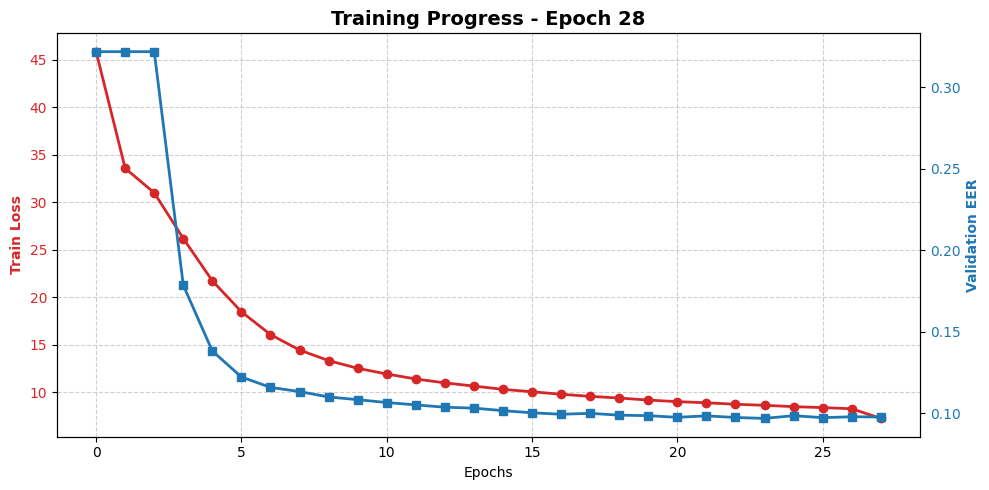

Epoch 28 - EER: 0.0976 | Threshold@1%FPR: 0.2771

Best EER so far: 0.0968

Monitored metric val_eer did not improve in the last 5 records. Best score: 0.097. Signaling Trainer to stop.
Epoch 28, global step 23374: 'val_eer' was not in top 1


Best model saved at: ../G2-ckpts/ECAPA-TDNN/best_model.ckpt
Đã trích xuất xong trọng số của backbone!


In [12]:
# 4. TRAINER & TRAINING 
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='gpu',
    devices=1, 
    callbacks=[checkpoint_callback, early_stop_callback, live_plot_callback],
    logger=False, 
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    precision="16-mixed",
    accumulate_grad_batches=4
)

trainer.fit(model, datamodule=dm)

# 5. TRÍCH XUẤT TRỌNG SỐ ĐÃ FINE-TUNED
best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model.ckpt")
print(f"Best model saved at: {best_ckpt_path}")

lightning_checkpoint = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)
state_dict = lightning_checkpoint['state_dict']

fine_tuned_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('backbone.'):
        fine_tuned_state_dict[k[9:]] = v

print("Đã trích xuất xong trọng số của backbone!")